# Linear Models for Regression 

In [161]:
# standard imports and configuration
import numpy as np
import pandas as pd
import mglearn
import matplotlib.pyplot as plt
import seaborn as sns; sns.set_style('white')
%matplotlib inline

    Linear models predict using a linear function of the input features:
    
    ŷ = w[0] * x[0] + w[1] * x[1] + ... + w[p] * x[p] + b

#### Ordinary Least Squares (OLS) 

In [162]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# sample one-dimensional dataset 
X, y = mglearn.datasets.make_wave(n_samples=60)
# partition dataset into train and test subsets; affix random state to reproduce results
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=22)
# instantiate linear regression class and fit model on training data
ols = LinearRegression().fit(X_train, y_train)

In [163]:
# view attributes derived from the regression estimator 
print('Coefficients w: {0}'.format(ols.coef_))
print('Intercept b: {0}'.format(ols.intercept_))

Coefficients w: [0.41740053]
Intercept b: -0.04953624501912423


In [164]:
# view training and test scores (coefficient of determination, R^2)
print('Training score: {:.2f}'.format(ols.score(X_train, y_train)))
print('Test set score: {:.2f}'.format(ols.score(X_test, y_test)))

Training score: 0.66
Test set score: 0.64


    Based on the training and test scores, the model is underfitting the data. This is because the model is very simple, as a line is usually insufficient in capturing the particularities of the dataset. While this model does not perform well on low-dimensional datasets, linear models in fact become more powerful as the number of features (dimensions) grow, as shown next.

In [165]:
# load a dataset with a large number of features
X, y = mglearn.datasets.load_extended_boston()

# view the shape of the feature space in 2D (104 features)
X.shape

(506, 104)

In [166]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=22)
ols = LinearRegression().fit(X_train, y_train)

In [167]:
print('Training set score: {:.2f}'.format(ols.score(X_train, y_train)))
print('Test set score: {:.2f}'.format(ols.score(X_test, y_test)))

Training set score: 0.93
Test set score: 0.73


    Although the linear regression model this time around performed quite well on the training set compared to the one-dimensional dataset explored earlier, there is evidently a large discrepancy between the training and test scores. Unlike in the previous example where the model was underfitting the data, the linear regression model in this example overfits the data. It tries too hard to Hence, the model tries too hard to imitate the dataset and is more representative of its peculiar noise properties rather than the underlying distribution which produced it. Hence, an alternative is required that enables one to control model complexity in order to obtain desired results based on the nature of the dataset being applied. This is where the Ridge and Lasso variants of the ordinary least squares regression model are used.

#### Ridge Regression

    Ridge regression relies on the same ordinarly least squares approach as before to make predictions however in this case an additional constraint is applied (L2-norm) to penalize large coefficients in order to produce a set of values (w) for the coefficients (x) that are diffuse (i.e., spread out) rather than one that is concentrated on only a small(er) number coefficients. This process is referred to as regularization. The parameter to control this feature within these regularized regression algorithms in scikit-learn is called alpha. A large alpha results in a set of values for the coefficients that are dispersed across multiple coefficients, resulting in a less complex (or in other words more restrictive) model, and vice-versa.

In [168]:
from sklearn.linear_model import Ridge

# instantiate class and try defaults parameters (alpha=1.0)

ridge_default = Ridge().fit(X_train, y_train)
print('Training set score: {:.2f}'.format(ridge_default.score(X_train, y_train)))
print('Test set score: {:.2f}'.format(ridge_default.score(X_test, y_test)))

Training set score: 0.86
Test set score: 0.83


    As shown above, the training score of Ridge is lower than that of the ordinary least squares model, while the test set score is higher. This confirms the intuition that Ridge is better able to 'generalize' compared to the unregularized regression model at the expense of worse training accuracy. Since we are only interested in generalization performance, we should choose Ridge over the LinearRegression model.

In [169]:
# try different values of alpha

ridge_alpha10 = Ridge(alpha=10).fit(X_train, y_train)
print('Training set score: {:.2f}'.format(ridge_alpha10.score(X_train, y_train)))
print('Test set score: {:.2f}'.format(ridge_alpha10.score(X_test, y_test)))

Training set score: 0.76
Test set score: 0.76


In [170]:
ridge_alpha01 = Ridge(alpha=0.1).fit(X_train, y_train)
print('Training set score: {:.2f}'.format(ridge_alpha01.score(X_train, y_train)))
print('Test set score: {:.2f}'.format(ridge_alpha01.score(X_test, y_test)))

Training set score: 0.90
Test set score: 0.84


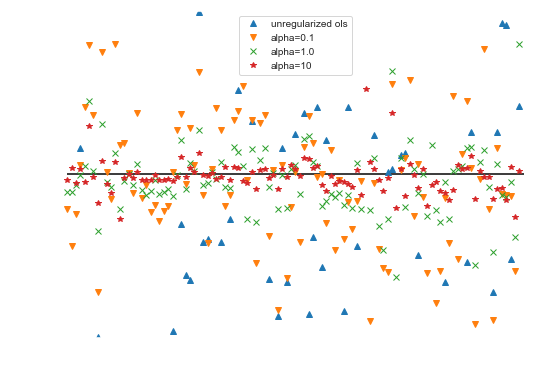

In [186]:
# plot the different values for the set of coefficients for each Ridge model for different values of alpha

fig, ax = plt.subplots(1, figsize=(9, 6), 
                       subplot_kw={'xlabel':'coefficient index', 'ylabel':'coefficient magnitude'})
ax.hlines(0, 0, len(ols.coef_))
ax.set_ylim(-15, 15)
ax.xaxis.label.set_color('white')
ax.yaxis.label.set_color('white')
ax.spines['bottom'].set_color('white')
ax.spines['top'].set_color('white') 
ax.spines['right'].set_color('white')
ax.spines['left'].set_color('white')
ax.xaxis.label.set_color('white')
ax.yaxis.label.set_color('white')
ax.tick_params(colors='white', which='both')
# or ax.xaxis.label.set_color('white'); ax.yaxis.label.set_color('white')

plt.plot(ols.coef_, '^', label='unregularized ols')
plt.plot(ridge_alpha01.coef_, 'v', label='alpha=0.1')
plt.plot(ridge_default.coef_, 'x', label='alpha=1.0')
plt.plot(ridge_alpha10.coef_, '*', label='alpha=10')

plt.legend(loc='best')

    From this graph, we can see that for larger values of alpha, the coefficients tend to become small. This translates to a less complex model, wheras lower values for alpha allows for the coefficient magnitudes to vary signficantly, hence the model is less restricted. Notice that for low values of alpha, the model tends to behave similarly to the unregularized ordinary least squares method.

#### Lasso Regression

    Lasso regression is similar to Ridge regression but instead applies a slightly different penalty (L1-norm). Due to geometric properties, one peculiar property of Lasso is that it forces some of the coefficients to become sparse (i.e., exactly zero). Hence, it peforms a crude form of feature selection. Like before, this complexity can be controlled by the alpha parameter.

In [172]:
from sklearn.linear_model import Lasso

# try various values of alpha and see the number of features used

lasso_default = Lasso().fit(X_train, y_train)
print('Training set score: {:.2f}'.format(lasso_default.score(X_train, y_train)))
print('Test set score: {:.2f}'.format(lasso_default.score(X_test, y_test)))
print('Number of features used: {0}'.format(np.sum(lasso_default.coef_ != 0)))

Training set score: 0.26
Test set score: 0.24
Number of features used: 3


In [173]:
lasso_alpha01 = Lasso(alpha=0.01, max_iter=100000).fit(X_train, y_train)
print('Training set score: {:.2f}'.format(lasso_alpha01.score(X_train, y_train)))
print('Test set score: {:.2f}'.format(lasso_alpha01.score(X_test, y_test)))
print('Number of features used: {0}'.format(np.sum(lasso_alpha01.coef_ != 0)))

Training set score: 0.88
Test set score: 0.81
Number of features used: 34


In [174]:
lasso_alpha0001 = Lasso(alpha=0.0001, max_iter=100000).fit(X_train, y_train)
print('Training set score: {:.2f}'.format(lasso_alpha0001.score(X_train, y_train)))
print('Test set score: {:.2f}'.format(lasso_alpha0001.score(X_test, y_test)))
print('Number of features used: {0}'.format(np.sum(lasso_alpha0001.coef_ != 0)))

Training set score: 0.93
Test set score: 0.78
Number of features used: 96


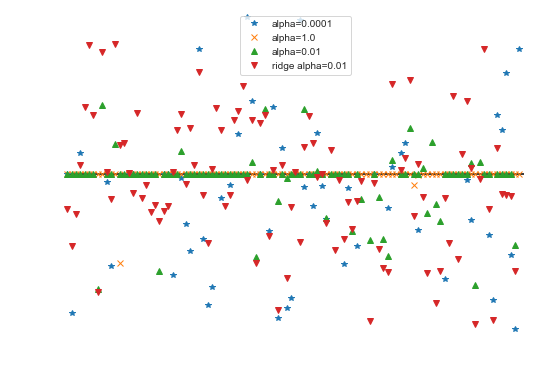

In [181]:
# plot the different values for the set of coefficients for each Lasso model for different values of alpha

fig, ax = plt.subplots(1, figsize=(9, 6), 
                       subplot_kw={'xlabel':'coefficient index', 'ylabel':'coefficient magnitude'})
ax.hlines(0, 0, len(ols.coef_))
ax.set_ylim(-15, 15)
ax.xaxis.label.set_color('white')
ax.yaxis.label.set_color('white')
ax.spines['bottom'].set_color('white')
ax.spines['top'].set_color('white') 
ax.spines['right'].set_color('white')
ax.spines['left'].set_color('white')
ax.xaxis.label.set_color('white')
ax.yaxis.label.set_color('white')
ax.tick_params(colors='white', which='both')
# or ax.xaxis.label.set_color('white'); ax.yaxis.label.set_color('white')

plt.plot(lasso_alpha0001.coef_, '*', label='alpha=0.0001')
plt.plot(lasso_default.coef_, 'x', label='alpha=1.0')
plt.plot(lasso_alpha01.coef_, '^', label='alpha=0.01')
plt.plot(ridge_alpha01.coef_, 'v', label='ridge alpha=0.01')

plt.legend(loc='best')

    Based on the above graph, we can see that Lasso is particularly more sensitive to the parameter alpha than Ridge is. Moreover, we observe that coefficients become zero for highly regularized Lasso models. This particular feature of Lasso can be useful if model interpretability is important.   